# EV Charging Locations — Silver Processing

This notebook explores, validates, and cleans the raw TfNSW EV charging
location dataset from the Bronze layer.

The goal is to produce a clean and validated Silver dataset suitable for
spatial processing and downstream analytics.

In [1]:
import sys
from pathlib import Path

print("Python:", sys.executable)
print("Working directory:", Path.cwd())

Python: D:\mycode\nsw-ev-data-pipeline\.conda\python.exe
Working directory: D:\mycode\nsw-ev-data-pipeline\notebooks


In [2]:
current_dir = Path.cwd().resolve()

for candidate in (current_dir, *current_dir.parents):
    if (candidate / "README.md").is_file() and (candidate / "src").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Project root could not be found.")

EV_BRONZE_DIR = PROJECT_ROOT / "data" / "bronze" / "ev"
EV_SILVER_DIR = PROJECT_ROOT / "data" / "silver" / "ev"

print("Project root:", PROJECT_ROOT)
print("EV Bronze:", EV_BRONZE_DIR)
print("EV Silver:", EV_SILVER_DIR)

Project root: D:\mycode\nsw-ev-data-pipeline
EV Bronze: D:\mycode\nsw-ev-data-pipeline\data\bronze\ev
EV Silver: D:\mycode\nsw-ev-data-pipeline\data\silver\ev


In [3]:
src_path = PROJECT_ROOT / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("src in sys.path:", str(src_path) in sys.path)

src in sys.path: True


## Step 1 — Locate the Bronze EV dataset

Locate the raw EV CSV downloaded by the Bronze acquisition pipeline.

In [4]:
ev_files = list(EV_BRONZE_DIR.glob("*.csv"))

print("CSV files found:", len(ev_files))

for file_path in ev_files:
    print(file_path.name)

CSV files found: 1
ev_20251216.csv


In [5]:
if len(ev_files) != 1:
    raise ValueError(
        f"Expected exactly one EV CSV file, found {len(ev_files)}"
    )

EV_BRONZE_FILE = ev_files[0]

print("Using:", EV_BRONZE_FILE)

Using: D:\mycode\nsw-ev-data-pipeline\data\bronze\ev\ev_20251216.csv


## Step 2 — Load and inspect the raw EV data

Load the Bronze CSV with pandas and inspect its shape, columns, data types,
and sample records before applying any transformations.

In [6]:
import pandas as pd

ev_raw = pd.read_csv(EV_BRONZE_FILE)

print("Rows:", len(ev_raw))
print("Columns:", len(ev_raw.columns))

Rows: 1958
Columns: 12


In [7]:
ev_raw.head()

,OBJECTID,Station_name,Station_address,Operator,Number_of_plugs,Charger_Type,Charger_rating,Latitude,Longitude,LGANAME,PCODE,Source
0,NaN,NaN,", Muswellbrook, 2333",EVUp,2,AC,22 kW,-32.262242,150.890139,Muswellbrook Shire Council,2333,Existing Destination Chargers
1,NaN,NaN,"01 Wallgrove Road, Sydney, 2766",BP,4,DC,150 kW,-33.811004,150.849597,Blacktown City Council,2766,Existing Fast Chargers
2,NaN,NaN,"1 - 7 Ross St, Wilcannia NSW 2836, Australia",NRMA,4,DC,50 kW,-30.511874,151.669395,Central Darling Shire Council,2350,TfNSW Regional
3,NaN,NaN,"1 Balfour St, Sydney, 2070",Chargefox,7,AC,22 kW,-33.774101,151.167035,Ku-ring-gai Council,2070,Existing Destination Chargers
4,NaN,NaN,"1 Bay Ln, Byron Bay, 2481",Tesla,2,AC,19 kW,-28.641819,153.613633,Byron Shire Council,2481,Existing Destination Chargers


In [8]:
ev_raw.columns.tolist()

['OBJECTID',
 'Station_name',
 'Station_address',
 'Operator',
 'Number_of_plugs',
 'Charger_Type',
 'Charger_rating',
 'Latitude',
 'Longitude',
 'LGANAME',
 'PCODE',
 'Source']

In [9]:
ev_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1958 entries, 0 to 1957
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OBJECTID         121 non-null    float64
 1   Station_name     520 non-null    str    
 2   Station_address  1958 non-null   str    
 3   Operator         1958 non-null   str    
 4   Number_of_plugs  1958 non-null   int64  
 5   Charger_Type     1958 non-null   str    
 6   Charger_rating   1958 non-null   str    
 7   Latitude         1958 non-null   float64
 8   Longitude        1958 non-null   float64
 9   LGANAME          1837 non-null   str    
 10  PCODE            1837 non-null   str    
 11  Source           1837 non-null   str    
dtypes: float64(3), int64(1), str(8)
memory usage: 387.4 KB


## Step 3 — Initial data quality assessment


Assess missing values, duplicate records, and basic descriptive statistics
before designing the cleaning rules.

In [10]:
missing_summary = (
    ev_raw
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_summary

OBJECTID           1837
Station_name       1438
Source              121
PCODE               121
LGANAME             121
Station_address       0
Operator              0
Number_of_plugs       0
Latitude              0
Charger_rating        0
Charger_Type          0
Longitude             0
dtype: int64

In [11]:
missing_percent = (
    ev_raw
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_percent

OBJECTID           93.820225
Station_name       73.442288
Source              6.179775
PCODE               6.179775
LGANAME             6.179775
Station_address     0.000000
Operator            0.000000
Number_of_plugs     0.000000
Latitude            0.000000
Charger_rating      0.000000
Charger_Type        0.000000
Longitude           0.000000
dtype: float64

In [12]:
duplicate_rows = ev_raw.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [13]:
ev_raw.describe()

,OBJECTID,Number_of_plugs,Latitude,Longitude
count,121.000000,1958.000000,1958.000000,1958.000000
mean,431.801653,2.873340,-33.484300,150.697229
std,231.138329,2.423335,1.588800,1.665905
min,11.000000,1.000000,-37.111463,141.460104
25%,238.000000,2.000000,-33.944959,150.486904
50%,445.000000,2.000000,-33.853122,151.156083
75%,603.000000,4.000000,-33.010212,151.266295
max,878.000000,35.000000,-28.168593,153.615875


## Step 4 — Investigate missing-value patterns

Investigate whether missing values are structural rather than random.

In particular, examine the relationship between `OBJECTID`, `Source`,
`PCODE`, and `LGANAME`, and inspect records where `Station_name` is missing
before defining any cleaning rules.

In [14]:
print("Rows with OBJECTID:")
print(ev_raw["OBJECTID"].notna().sum())

print("\nOBJECTID present + Source missing:")
print(
    (
        ev_raw["OBJECTID"].notna()
        & ev_raw["Source"].isna()
    ).sum()
)

print("\nOBJECTID present + PCODE missing:")
print(
    (
        ev_raw["OBJECTID"].notna()
        & ev_raw["PCODE"].isna()
    ).sum()
)

print("\nOBJECTID present + LGANAME missing:")
print(
    (
        ev_raw["OBJECTID"].notna()
        & ev_raw["LGANAME"].isna()
    ).sum()
)

Rows with OBJECTID:
121

OBJECTID present + Source missing:
121

OBJECTID present + PCODE missing:
121

OBJECTID present + LGANAME missing:
121


In [15]:
ev_raw.loc[
    ev_raw["OBJECTID"].notna(),
    [
        "OBJECTID",
        "Station_name",
        "Station_address",
        "Operator",
        "PCODE",
        "LGANAME",
        "Source",
        "Latitude",
        "Longitude",
    ]
].head(10)

,OBJECTID,Station_name,Station_address,Operator,PCODE,LGANAME,Source,Latitude,Longitude
983,11.0,NaN,"422 Pacific Hwy, Artarmon NSW 2064, Australia",BP Australia,NaN,NaN,NaN,-33.811419,151.175608
984,18.0,NaN,129 Pacific Hwy Ourimbah NSW 2258 Australia,NRMA Electric,NaN,NaN,NaN,-33.353198,151.369026
985,22.0,NaN,"4974 Pacific Hwy, Halfway Creek NSW 2460, Aust...",Viva Energy A,NaN,NaN,NaN,-29.934883,153.094795
986,33.0,NaN,"Stoney Creek Road Car Park, 497 Forest Rd, Bex...",Fast Cities A,NaN,NaN,NaN,-33.949337,151.116336
987,42.0,NaN,"491 Masonite Rd, Heatherbrae NSW 2324, Australia",Tesla Motors,NaN,NaN,NaN,-32.783057,151.737598
988,55.0,NaN,Ross Smith Ave Mascot NSW 2020 Australia,Tesla Motors,NaN,NaN,NaN,-33.938008,151.192479
989,68.0,NaN,88 Smithfield Rd Smithfield NSW 2164 Australia,NRMA Electric,NaN,NaN,NaN,-33.855681,150.937188
990,69.0,NaN,"3 Carlton Cres, Summer Hill, NSW, 2130, Australia",BP Australia,NaN,NaN,NaN,-33.892348,151.143119
991,72.0,NaN,"135 Fairfield Rd, Guildford West 2161, NSW",Fast Cities A,NaN,NaN,NaN,-33.850991,150.959781
992,90.0,NaN,Campbell Pde\nBondi Beach NSW 2026\nAustralia,Fast Cities A,NaN,NaN,NaN,-33.889730,151.279759


In [16]:
ev_raw.loc[
    ev_raw["OBJECTID"].isna(),
    [
        "OBJECTID",
        "Station_name",
        "Station_address",
        "Operator",
        "PCODE",
        "LGANAME",
        "Source",
        "Latitude",
        "Longitude",
    ]
].head(10)

,OBJECTID,Station_name,Station_address,Operator,PCODE,LGANAME,Source,Latitude,Longitude
0,NaN,NaN,", Muswellbrook, 2333",EVUp,2333,Muswellbrook Shire Council,Existing Destination Chargers,-32.262242,150.890139
1,NaN,NaN,"01 Wallgrove Road, Sydney, 2766",BP,2766,Blacktown City Council,Existing Fast Chargers,-33.811004,150.849597
2,NaN,NaN,"1 - 7 Ross St, Wilcannia NSW 2836, Australia",NRMA,2350,Central Darling Shire Council,TfNSW Regional,-30.511874,151.669395
3,NaN,NaN,"1 Balfour St, Sydney, 2070",Chargefox,2070,Ku-ring-gai Council,Existing Destination Chargers,-33.774101,151.167035
4,NaN,NaN,"1 Bay Ln, Byron Bay, 2481",Tesla,2481,Byron Shire Council,Existing Destination Chargers,-28.641819,153.613633
5,NaN,NaN,"1 Bay St, Sydney, 2037",Tesla,2037,"Sydney, Council of the City of",Existing Fast Chargers,-33.883504,151.194433
6,NaN,NaN,"1 Bells Blvd, Kingscliff, 2487",Evie,2487,Tweed Shire Council,Existing Fast Chargers,-28.276903,153.577078
7,NaN,NaN,"1 Bradleys Head Rd, Sydney, 2088",Chargefox,2088,Mosman Municipal Council,Existing Destination Chargers,-33.841037,151.242245
8,NaN,NaN,"1 Bradleys Head Rd, Sydney, 2088",Chargefox,2088,Mosman Municipal Council,Existing Destination Chargers,-33.841418,151.242631
9,NaN,NaN,"1 Cathedral Sq, Sydney, 2000",AXCharge,2000,"Sydney, Council of the City of",Existing Destination Chargers,-33.871368,151.213741


In [17]:
ev_raw.loc[
    ev_raw["Station_name"].isna(),
    [
        "Station_name",
        "Station_address",
        "Operator",
        "Number_of_plugs",
        "Charger_Type",
        "Charger_rating",
        "Latitude",
        "Longitude",
    ]
].head(15)

,Station_name,Station_address,Operator,Number_of_plugs,Charger_Type,Charger_rating,Latitude,Longitude
0,NaN,", Muswellbrook, 2333",EVUp,2,AC,22 kW,-32.262242,150.890139
1,NaN,"01 Wallgrove Road, Sydney, 2766",BP,4,DC,150 kW,-33.811004,150.849597
2,NaN,"1 - 7 Ross St, Wilcannia NSW 2836, Australia",NRMA,4,DC,50 kW,-30.511874,151.669395
3,NaN,"1 Balfour St, Sydney, 2070",Chargefox,7,AC,22 kW,-33.774101,151.167035
4,NaN,"1 Bay Ln, Byron Bay, 2481",Tesla,2,AC,19 kW,-28.641819,153.613633
5,NaN,"1 Bay St, Sydney, 2037",Tesla,16,DC,130 kW,-33.883504,151.194433
6,NaN,"1 Bells Blvd, Kingscliff, 2487",Evie,4,DC,75 kW,-28.276903,153.577078
7,NaN,"1 Bradleys Head Rd, Sydney, 2088",Chargefox,1,AC,22 kW,-33.841037,151.242245
8,NaN,"1 Bradleys Head Rd, Sydney, 2088",Chargefox,1,AC,22 kW,-33.841418,151.242631
9,NaN,"1 Cathedral Sq, Sydney, 2000",AXCharge,3,AC,22 kW,-33.871368,151.213741


In [18]:
ev_raw.loc[
    ev_raw["Station_name"].notna(),
    [
        "Station_name",
        "Station_address",
        "Operator",
        "Number_of_plugs",
        "Charger_Type",
        "Charger_rating",
        "Latitude",
        "Longitude",
    ]
].head(15)

,Station_name,Station_address,Operator,Number_of_plugs,Charger_Type,Charger_rating,Latitude,Longitude
118,Reflections Coffs Harbour,123 Pacific Hwy\nCoffs Harbour NSW 2450\nAustr...,Non-networked,4,AC,AC,-30.293063,153.120009
152,Denman Van Village,14 Macauley St\nDenman NSW 2328\nAustralia,Non-networked,2,AC,AC,-32.394325,150.684767
414,Thynk Beresfield,3 Bowden Way\nBeresfield NSW 2322\nAustralia,Non-networked,3,AC,AC,-32.802623,151.633290
530,Hay Shire Council,406 Moppett St\nHay NSW 2711\nAustralia,Exploren,4,AC,AC,-34.508956,144.842843
604,Albury City Council,520 David St\nAlbury NSW 2640\nAustralia,Exploren,4,AC,AC,-36.080635,146.921609
691,Symbio Wildlife Park,7-11 Lawrence Hargrave Dr\nHelensburgh NSW 250...,360 EV Charge,4,AC,AC,-34.205481,150.968701
700,Roxy Theatre,74 Maitland St\nBingara NSW 2404\nAustralia,Exploren,2,AC,AC,-29.869128,150.571434
775,Reflections Bonny Hills,920 Ocean Dr\nBonny Hills NSW 2445\nAustralia,Non-networked,4,AC,AC,-31.591344,152.840253
815,Kempsey Shire Council,Buchanan Dr\nSouth West Rocks NSW 2431\nAustralia,Exploren,2,AC,AC,-30.886530,153.037957
980,Jac & Jones Wines Hunter Valley,"771 Hermitage Rd, Pokolbin NSW 2320",Non-networked,1,AC,AC,-32.716558,151.257288


In [19]:
export_path = PROJECT_ROOT / "ev_raw_for_review.csv"

ev_raw.to_csv(
    export_path,
    index=False,
    encoding="utf-8"
)

print(export_path)

D:\mycode\nsw-ev-data-pipeline\ev_raw_for_review.csv


## Step 4 — Preliminary data quality findings

The initial assessment suggests that missing values are largely structural
rather than random.

The dataset appears to contain two record structures:

- 121 records contain `OBJECTID` but have no `Source`, `PCODE`, or `LGANAME`.
- The remaining 1,837 records have `Source`, `PCODE`, and `LGANAME`, but no
  `OBJECTID`.

Therefore, rows should not be removed solely because these fields are missing.

`Station_name` is also missing for a large proportion of records, but all
records contain an address and coordinates. Therefore, a missing station name
does not necessarily indicate an invalid charging location.

These findings provide preliminary guidance for Silver processing. Before
finalising the cleaning rules, targeted visual exploratory data analysis will
be used to examine missingness, category distributions, numerical values,
spatial coverage, and potential anomalies.

## Step 5 — Visual exploratory data analysis


Use targeted visualisations to further investigate the raw EV dataset before
finalising the Silver cleaning rules.

The analysis focuses on:

- missing-value patterns;
- charger-type distribution;
- number-of-plugs distribution;
- operator frequency;
- spatial distribution of charging locations;
- potential duplicate locations.

In [20]:
import matplotlib.pyplot as plt

In [21]:
import sys
print(sys.executable)

D:\mycode\nsw-ev-data-pipeline\.conda\python.exe


### 5.1 Missing-value distribution

Visualise the proportion of missing values across columns to identify fields
with substantial missingness and distinguish them from complete core attributes.

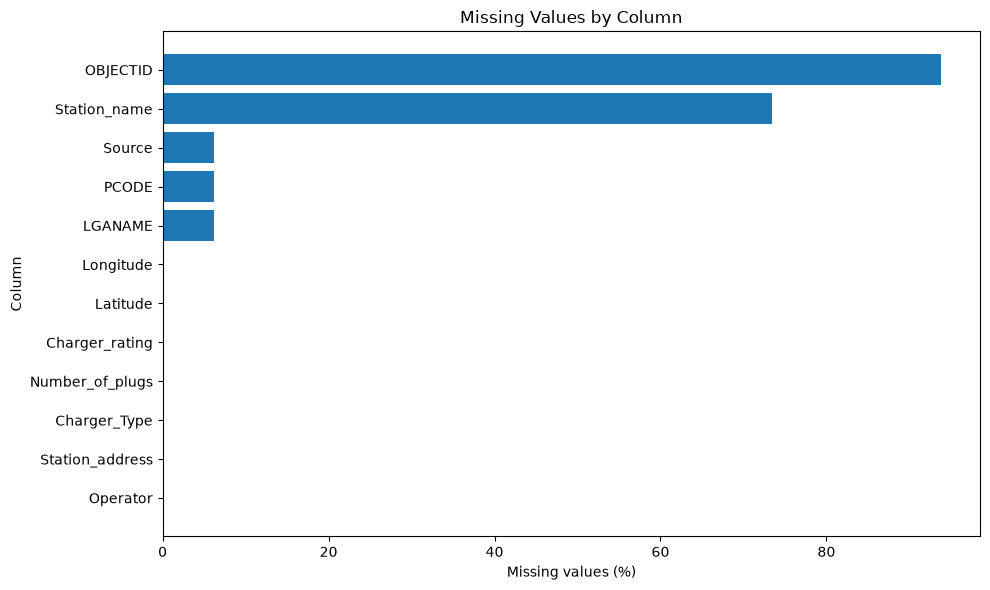

In [22]:
missing_percent_sorted = (
    ev_raw
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    missing_percent_sorted.index,
    missing_percent_sorted.values
)

plt.xlabel("Missing values (%)")
plt.ylabel("Column")
plt.title("Missing Values by Column")

plt.tight_layout()
plt.show()

### 5.2 Charger-type distribution

Inspect the distribution of `Charger_Type` to determine whether the field
contains only charger technologies or also values representing deployment status.

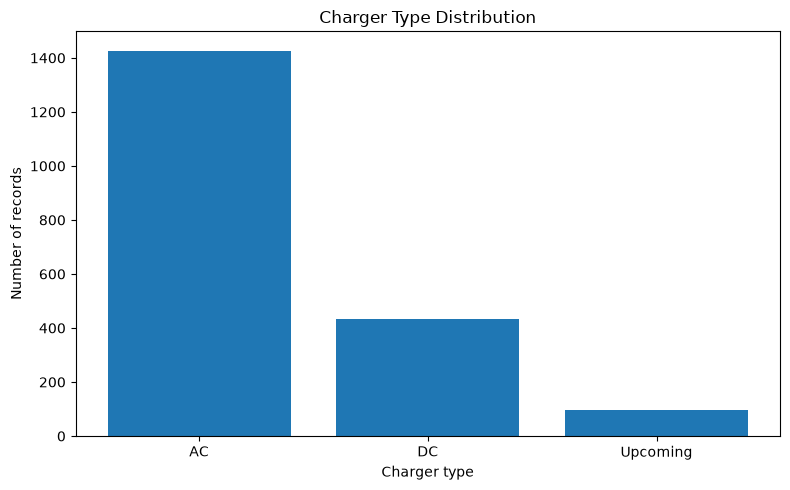

Charger_Type
AC          1427
DC           433
Upcoming      98
Name: count, dtype: int64

In [23]:
charger_type_counts = (
    ev_raw["Charger_Type"]
    .value_counts(dropna=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    charger_type_counts.index.astype(str),
    charger_type_counts.values
)

plt.xlabel("Charger type")
plt.ylabel("Number of records")
plt.title("Charger Type Distribution")

plt.tight_layout()
plt.show()

charger_type_counts

### 5.3 Number-of-plugs distribution

Inspect the distribution of `Number_of_plugs` to identify unusual values and
determine whether high values are plausible observations rather than data errors.

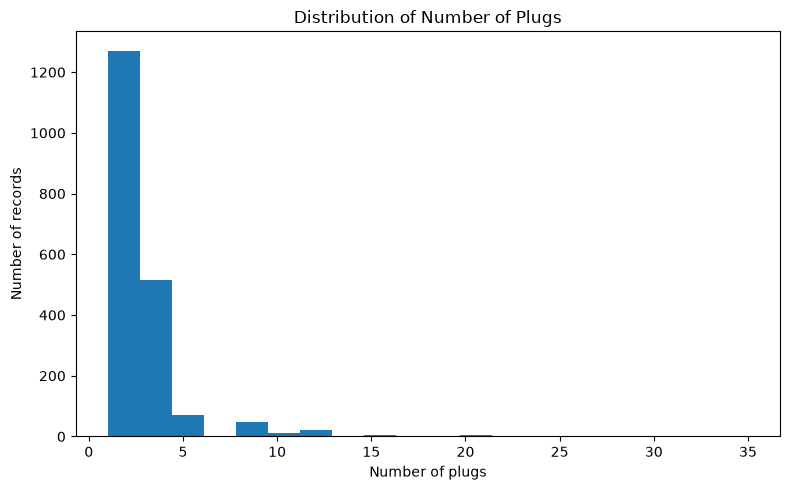

In [24]:
plt.figure(figsize=(8, 5))

plt.hist(
    ev_raw["Number_of_plugs"],
    bins=20
)

plt.xlabel("Number of plugs")
plt.ylabel("Number of records")
plt.title("Distribution of Number of Plugs")

plt.tight_layout()
plt.show()

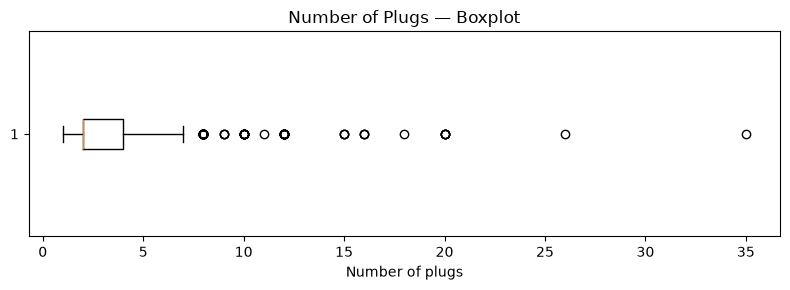

In [25]:
plt.figure(figsize=(8, 3))

plt.boxplot(
    ev_raw["Number_of_plugs"],
    orientation="horizontal"
)

plt.xlabel("Number of plugs")
plt.title("Number of Plugs — Boxplot")

plt.tight_layout()
plt.show()

**Observation:**  
`Number_of_plugs` is strongly right-skewed. Most charging locations contain
a small number of plugs, while several locations have substantially higher
values.

These high-value observations are statistical outliers, but they should not
be removed automatically because large charging sites may legitimately contain
many plugs.

### 5.4 Operator distribution

Inspect the most frequent charging operators and identify possible naming
inconsistencies, such as whitespace differences or alternative names for the
same organisation.

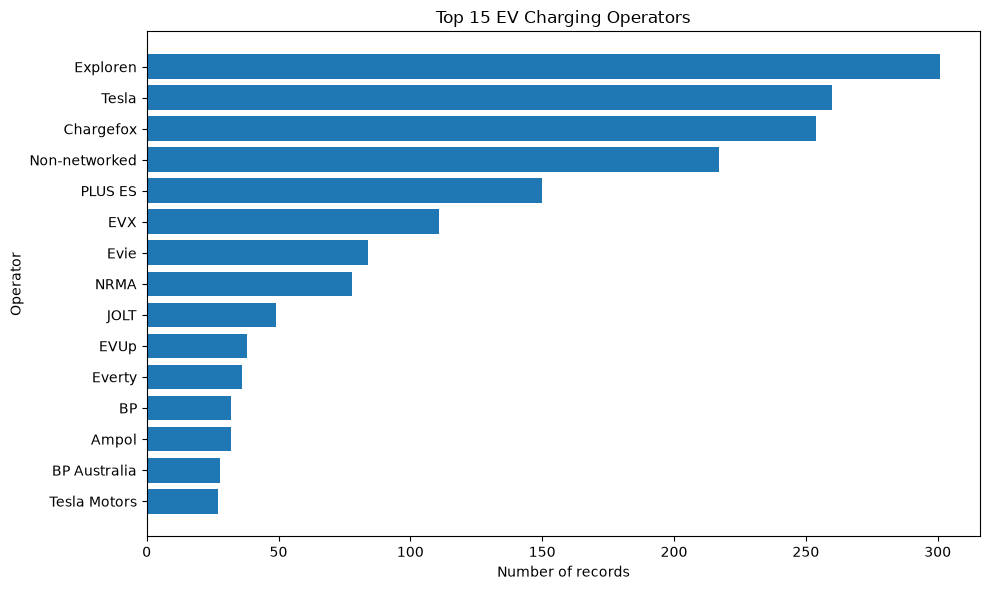

Operator
Exploren         301
Tesla            260
Chargefox        254
Non-networked    217
PLUS ES          150
EVX              111
Evie              84
NRMA              78
JOLT              49
EVUp              38
Everty            36
BP                32
Ampol             32
BP Australia      28
Tesla Motors      27
Name: count, dtype: int64[pyarrow]

In [26]:
operator_preview = (
    ev_raw["Operator"]
    .astype("string")
    .str.strip()
)

top_operators = (
    operator_preview
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_operators.index[::-1],
    top_operators.values[::-1]
)

plt.xlabel("Number of records")
plt.ylabel("Operator")
plt.title("Top 15 EV Charging Operators")

plt.tight_layout()
plt.show()

top_operators

**Observation:**  
The operator distribution is concentrated among a relatively small number of
major charging networks.

Potential naming inconsistencies are also visible. For example, `Tesla` and
`Tesla Motors`, as well as `BP` and `BP Australia`, appear as separate
categories.

These values should not be merged automatically during EDA. Instead, operator
names will first be normalised for whitespace and then reviewed using an
explicit alias mapping during Silver processing.

### 5.5 Spatial distribution of charging locations

Plot longitude against latitude to inspect the geographical distribution of EV
charging locations and identify possible coordinate anomalies, isolated points,
or unusual spatial patterns.

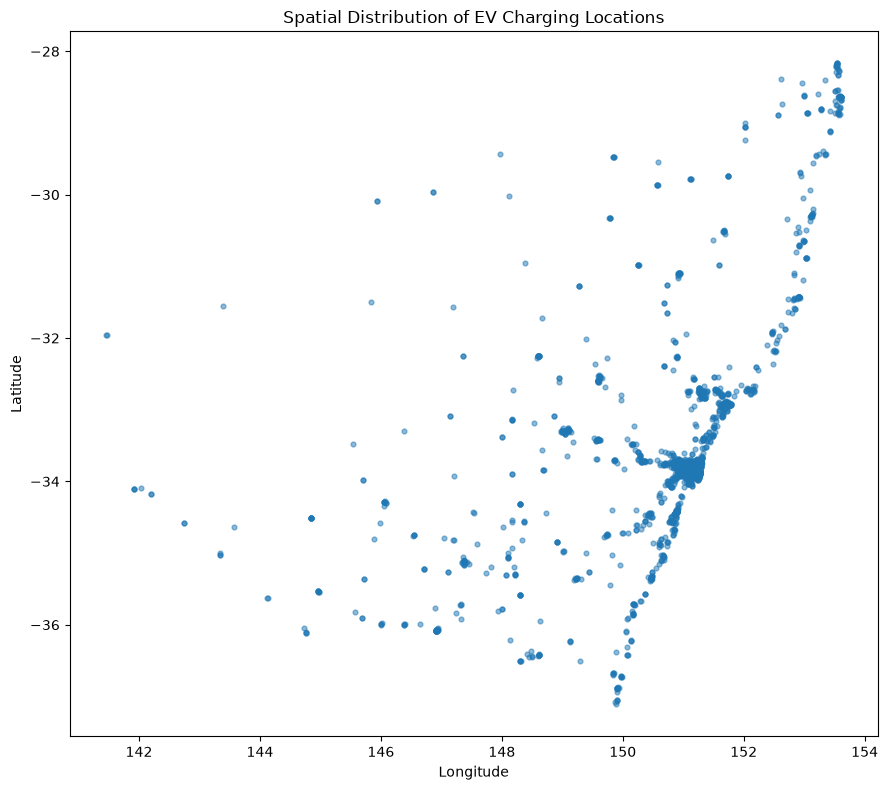

In [27]:
plt.figure(figsize=(9, 8))

plt.scatter(
    ev_raw["Longitude"],
    ev_raw["Latitude"],
    s=12,
    alpha=0.5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of EV Charging Locations")

plt.tight_layout()
plt.show()

**Observation:**  
The charging locations show a plausible spatial pattern for New South Wales,
with strong concentration along the eastern coast and major metropolitan areas
and a lower density across inland regions.

No obvious extreme coordinate anomalies are visible in the scatter plot.
However, visual inspection alone is not sufficient to confirm that every
record lies within NSW. A polygon-based spatial validation will be performed
later using the ABS boundary dataset.

### 5.6 Potential duplicate locations

Investigate repeated latitude-longitude combinations.

Repeated coordinates are not automatically treated as duplicate records,
because the same physical charging location may contain multiple charger types,
operators, or source records.

In [28]:
coordinate_counts = (
    ev_raw
    .groupby(["Latitude", "Longitude"])
    .size()
    .sort_values(ascending=False)
)

coordinate_counts.head(20)

Latitude    Longitude 
-34.407957  150.877135    3
-34.436615  150.863298    3
-33.909859  151.141688    2
-33.888574  151.244410    2
-33.885391  151.132238    2
-33.858428  151.186886    2
-34.508956  144.842843    2
-33.924232  151.226679    2
-33.855622  151.076796    2
-34.286631  146.044525    2
-36.080635  146.921609    2
-33.807393  151.200067    2
-33.794945  151.188291    2
-33.393116  151.328631    2
-32.923023  151.757234    2
-32.716558  151.257288    2
-30.886530  153.037957    2
-29.869128  150.571434    2
-28.215101  153.540438    1
-28.212505  153.530593    1
dtype: int64

In [29]:
repeated_coordinates = coordinate_counts[
    coordinate_counts > 1
]

print(
    "Coordinates appearing more than once:",
    len(repeated_coordinates)
)

print(
    "Records involved in repeated coordinates:",
    repeated_coordinates.sum()
)

Coordinates appearing more than once: 18
Records involved in repeated coordinates: 38


In [30]:
duplicate_coordinate_pairs = repeated_coordinates.index

duplicate_location_records = ev_raw[
    ev_raw.set_index(["Latitude", "Longitude"]).index.isin(
        duplicate_coordinate_pairs
    )
].sort_values(
    ["Latitude", "Longitude"]
)

duplicate_location_records[
    [
        "Station_name",
        "Station_address",
        "Operator",
        "Number_of_plugs",
        "Charger_Type",
        "Charger_rating",
        "Latitude",
        "Longitude",
    ]
].head(30)

,Station_name,Station_address,Operator,Number_of_plugs,Charger_Type,Charger_rating,Latitude,Longitude
604,Albury City Council,520 David St\nAlbury NSW 2640\nAustralia,Exploren,4,AC,AC,-36.080635,146.921609
1087,Albury City Council,"520 David St, Albury NSW 2640, Australia",Exploren,2,AC,7,-36.080635,146.921609
530,Hay Shire Council,406 Moppett St\nHay NSW 2711\nAustralia,Exploren,4,AC,AC,-34.508956,144.842843
1073,Hay Shire Council,"406 Moppett St, Hay NSW 2711, Australia",Exploren,2,AC,22,-34.508956,144.842843
245,NaN,"19 Princes Hwy, Figtree NSW 2525, Australia",Tesla,6,DC,175 kW,-34.436615,150.863298
1088,NaN,"19 Princes Hwy, Figtree NSW 2525, Australia",Tesla Motors,6,DC,2x350kW & 2x175kW,-34.436615,150.863298
1150,Figtree Grove Shopping Centre,"19 Princes Hwy, Figtree NSW 2525",Non-networked,2,AC,AC,-34.436615,150.863298
967,NaN,"University of Wollongong, Northfields Avenue, ...",Chargefox,6,DC,175 kW,-34.407957,150.877135
1061,NaN,"University of Wollongong, Northfields Avenue, ...",University of,6,DC,2x350kW & 2x175kW,-34.407957,150.877135
1775,Early Start Discovery Space,Early Start Discovery Space (Building 21) Univ...,Chargefox,4,AC,AC,-34.407957,150.877135


**Observation:**  
There are 18 latitude-longitude combinations that occur more than once,
involving 38 records in total.

Inspection of these records shows that repeated coordinates do not necessarily
represent exact duplicates. Some records at the same location differ in
attributes such as `Number_of_plugs`, charger type, or source information.

Therefore, repeated coordinates will be treated as potential duplicate
locations rather than automatically removed. Duplicate handling will use
multiple attributes and will preserve ambiguous cases for downstream analysis.

## Step 6 — Define final Silver cleaning rules

Based on the tabular assessment and visual exploratory analysis, the Silver
processing stage will preserve valid source records while standardising fields
required for downstream spatial processing and analytics.

The following cleaning rules will be applied:

- Preserve records with missing `OBJECTID`, `Station_name`, `Source`, `PCODE`,
  or `LGANAME` when valid location information is available.
- Standardise column names using a consistent naming convention.
- Trim leading and trailing whitespace from text fields.
- Preserve important raw values when transformations may lose source
  information.
- Standardise postcode representation while retaining the original postcode.
- Separate charger technology (`AC` / `DC`) from deployment status such as
  `Upcoming`.
- Preserve the original charger-rating field and derive structured charging
  power attributes separately.
- Validate that `Number_of_plugs` contains positive and plausible values;
  statistical outliers will not be removed automatically.
- Validate latitude and longitude values before spatial processing.
- Treat repeated coordinates as potential duplicate locations rather than
  automatically deleting them.
- Standardise obvious operator formatting differences, while using an explicit
  alias mapping for operator-name consolidation.

## Step 7 — Apply Silver cleaning transformations

Create a separate working copy of the Bronze dataset and apply the Silver
cleaning rules without modifying the original raw DataFrame.

In [31]:
ev_clean = ev_raw.copy()

print("Raw shape:", ev_raw.shape)
print("Silver working shape:", ev_clean.shape)

Raw shape: (1958, 12)
Silver working shape: (1958, 12)


### 7.1 Standardise column names

Rename source columns using a consistent `snake_case` convention.

Fields that will later be transformed are explicitly marked as raw so that
the original source values remain available for auditing and comparison.

In [32]:
column_mapping = {
    "OBJECTID": "source_object_id",
    "Station_name": "station_name",
    "Station_address": "station_address",
    "Operator": "operator_raw",
    "Number_of_plugs": "number_of_plugs",
    "Charger_Type": "charger_type_raw",
    "Charger_rating": "charger_rating_raw",
    "Latitude": "latitude",
    "Longitude": "longitude",
    "LGANAME": "lga_name_raw",
    "PCODE": "postcode_raw",
    "Source": "source",
}

ev_clean = ev_clean.rename(columns=column_mapping)

ev_clean.columns.tolist()

['source_object_id',
 'station_name',
 'station_address',
 'operator_raw',
 'number_of_plugs',
 'charger_type_raw',
 'charger_rating_raw',
 'latitude',
 'longitude',
 'lga_name_raw',
 'postcode_raw',
 'source']

In [33]:
ev_clean.head()

,source_object_id,station_name,station_address,operator_raw,number_of_plugs,charger_type_raw,charger_rating_raw,latitude,longitude,lga_name_raw,postcode_raw,source
0,NaN,NaN,", Muswellbrook, 2333",EVUp,2,AC,22 kW,-32.262242,150.890139,Muswellbrook Shire Council,2333,Existing Destination Chargers
1,NaN,NaN,"01 Wallgrove Road, Sydney, 2766",BP,4,DC,150 kW,-33.811004,150.849597,Blacktown City Council,2766,Existing Fast Chargers
2,NaN,NaN,"1 - 7 Ross St, Wilcannia NSW 2836, Australia",NRMA,4,DC,50 kW,-30.511874,151.669395,Central Darling Shire Council,2350,TfNSW Regional
3,NaN,NaN,"1 Balfour St, Sydney, 2070",Chargefox,7,AC,22 kW,-33.774101,151.167035,Ku-ring-gai Council,2070,Existing Destination Chargers
4,NaN,NaN,"1 Bay Ln, Byron Bay, 2481",Tesla,2,AC,19 kW,-28.641819,153.613633,Byron Shire Council,2481,Existing Destination Chargers


In [34]:
print("Rows:", len(ev_clean))
print("Columns:", len(ev_clean.columns))

Rows: 1958
Columns: 12


### 7.2 Standardise text fields

Standardise text formatting while preserving source values stored in the
`*_raw` columns.

Leading and trailing whitespace will be removed, and repeated whitespace
or line breaks in selected text fields will be normalised to a single space.
Cleaned analytical fields will be derived separately from the raw source fields.

In [35]:
def clean_text(series):
    return (
        series
        .astype("string")
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

In [36]:
ev_clean["station_name"] = clean_text(
    ev_clean["station_name"]
)

ev_clean["station_address"] = clean_text(
    ev_clean["station_address"]
)

ev_clean["source"] = clean_text(
    ev_clean["source"]
)

In [37]:
ev_clean["operator"] = clean_text(
    ev_clean["operator_raw"]
)

ev_clean["lga_name"] = clean_text(
    ev_clean["lga_name_raw"]
)

In [38]:
ev_clean[
    [
        "station_name",
        "station_address",
        "operator_raw",
        "operator",
        "lga_name_raw",
        "lga_name",
    ]
].head(10)

,station_name,station_address,operator_raw,operator,lga_name_raw,lga_name
0,<NA>,", Muswellbrook, 2333",EVUp,EVUp,Muswellbrook Shire Council,Muswellbrook Shire Council
1,<NA>,"01 Wallgrove Road, Sydney, 2766",BP,BP,Blacktown City Council,Blacktown City Council
2,<NA>,"1 - 7 Ross St, Wilcannia NSW 2836, Australia",NRMA,NRMA,Central Darling Shire Council,Central Darling Shire Council
3,<NA>,"1 Balfour St, Sydney, 2070",Chargefox,Chargefox,Ku-ring-gai Council,Ku-ring-gai Council
4,<NA>,"1 Bay Ln, Byron Bay, 2481",Tesla,Tesla,Byron Shire Council,Byron Shire Council
5,<NA>,"1 Bay St, Sydney, 2037",Tesla,Tesla,"Sydney, Council of the City of","Sydney, Council of the City of"
6,<NA>,"1 Bells Blvd, Kingscliff, 2487",Evie,Evie,Tweed Shire Council,Tweed Shire Council
7,<NA>,"1 Bradleys Head Rd, Sydney, 2088",Chargefox,Chargefox,Mosman Municipal Council,Mosman Municipal Council
8,<NA>,"1 Bradleys Head Rd, Sydney, 2088",Chargefox,Chargefox,Mosman Municipal Council,Mosman Municipal Council
9,<NA>,"1 Cathedral Sq, Sydney, 2000",AXCharge,AXCharge,"Sydney, Council of the City of","Sydney, Council of the City of"


#### Address punctuation check

Inspect addresses with leading or trailing punctuation introduced by incomplete
source address components.

In [39]:
leading_or_trailing_comma = (
    ev_clean["station_address"]
    .str.match(r"^\s*,", na=False)
    | ev_clean["station_address"].str.match(r".*,\s*$", na=False)
)

print(
    "Addresses with leading/trailing comma:",
    leading_or_trailing_comma.sum()
)

ev_clean.loc[
    leading_or_trailing_comma,
    ["station_address"]
].head(20)

Addresses with leading/trailing comma: 2


,station_address
0,", Muswellbrook, 2333"
754,"89 Barwan St, Narrabri, NSW 2390, Australia,"


#### Clean address punctuation artifacts

Remove redundant leading or trailing commas from `station_address` while
preserving valid punctuation inside the address.

Incomplete addresses will be retained rather than inferred or deleted.

In [40]:
ev_clean["station_address"] = (
    ev_clean["station_address"]
    .str.replace(r"^[,\s]+", "", regex=True)
    .str.replace(r"[,\s]+$", "", regex=True)
)

In [41]:
print(
    "Addresses still starting with comma:",
    ev_clean["station_address"]
    .str.match(r"^\s*,", na=False)
    .sum()
)

print(
    "Addresses still ending with comma:",
    ev_clean["station_address"]
    .str.match(r".*,\s*$", na=False)
    .sum()
)

Addresses still starting with comma: 0
Addresses still ending with comma: 0


In [42]:
ev_clean.loc[
    [0, 754],
    ["station_address"]
]

,station_address
0,"Muswellbrook, 2333"
754,"89 Barwan St, Narrabri, NSW 2390, Australia"


In [43]:
ev_clean["address_needs_review"] = (
    ev_clean["station_address"].notna()
    & ~ev_clean["station_address"].str.contains(
        r"\d+\s+\S+",
        regex=True,
        na=False
    )
)

In [44]:
print(
    "Addresses needing review:",
    ev_clean["address_needs_review"].sum()
)

Addresses needing review: 231


In [45]:
ev_clean.loc[
    ev_clean["address_needs_review"],
    [
        "station_name",
        "station_address",
        "operator",
        "latitude",
        "longitude",
    ]
].head(30)

,station_name,station_address,operator,latitude,longitude
0,<NA>,"Muswellbrook, 2333",EVUp,-32.262242,150.890139
75,<NA>,"10B Charles St, Sydney, 2193",Exploren,-33.911711,151.117292
76,<NA>,"10W Apsley St, Walcha NSW 2354, Australia",NRMA,-29.960127,146.857889
195,<NA>,"15c Mitchell St, Bourke, NSW 2840, Australia",NRMA,-30.338373,152.712541
196,<NA>,"1-5R Knowles Ave, Sydney, 2036",Chargefox,-33.957236,151.237237
240,<NA>,"18A Gould Dr, Lemon Tree Passage, 2319",Exploren,-32.733602,152.033681
257,<NA>,"19A Sirius Rd, Sydney, 2066",Exploren,-33.810182,151.146065
258,<NA>,"1A Bridges Rd, Gerringong, 2534",Exploren,-34.742446,150.831547
259,<NA>,"1a Duck St, Sydney, 2144",Tesla,-33.836954,151.027035
343,<NA>,"22A Clovelly Rd, Sydney, 2031",Exploren,-33.903637,151.242633


In [46]:
ev_clean = ev_clean.drop(
    columns=["address_needs_review"],
    errors="ignore"
)

In [47]:
locality_only_pattern = (
    r"^[A-Za-z .'-]+,\s*\d{4}$"
)

ev_clean["address_needs_review"] = (
    ev_clean["station_address"]
    .str.fullmatch(
        locality_only_pattern,
        case=False,
        na=False
    )
)

In [48]:
print(
    "Addresses needing review:",
    ev_clean["address_needs_review"].sum()
)

ev_clean.loc[
    ev_clean["address_needs_review"],
    [
        "station_name",
        "station_address",
        "operator",
        "latitude",
        "longitude",
    ]
].head(30)

Addresses needing review: 1


,station_name,station_address,operator,latitude,longitude
0,<NA>,"Muswellbrook, 2333",EVUp,-32.262242,150.890139


**Validation result:**  
The conservative address-quality rule identified only one clearly incomplete
address: `Muswellbrook, 2333`.

The record is retained because valid latitude and longitude coordinates are
available for downstream spatial processing. The address is flagged for review
rather than imputed or removed.

### 7.3 Standardise postcode values

Create a standardised four-digit postcode field while preserving the original
`postcode_raw` value.

Only formatting differences will be corrected at this stage. Postcode values
that conflict with information contained in the address will be identified
separately rather than silently overwritten.

In [49]:
postcode_text = (
    ev_clean["postcode_raw"]
    .astype("string")
    .str.strip()
)

non_standard_postcodes = ev_clean.loc[
    postcode_text.notna()
    & ~postcode_text.str.fullmatch(r"\d{4}", na=False),
    [
        "station_address",
        "postcode_raw",
    ]
]

print(
    "Non-standard postcode values:",
    len(non_standard_postcodes)
)

non_standard_postcodes

Non-standard postcode values: 10


,station_address,postcode_raw
58,"10 Victoria St, Wollongong , NSW 2500",NSW 2500
151,"14 George St, Wollongong, NSW 2500",NSW 2500
293,"20 Ocean St, Merewether, NSW 2291",NSW 2291
367,"25 Childe St, Byron Bay , NSW 2481",NSW 2481
477,"345 Lawrence Hargrave Dr, Thirroul , NSW 2515",NSW 2515
669,"66 Cliff Rd, Wollongong , NSW 2500",NSW 2500
779,"94 Booner St, Hawks Nest, NSW 2324",NSW 2324
839,"Cowper Street, Warrawong, NSW 2502",NSW 2502
955,"Smith St, Newcastle West, NSW 2303",NSW 2303
978,"Wordsworth St, Byron Bay, NSW 2481",NSW 2481


In [50]:
ev_clean["postcode"] = (
    postcode_text
    .str.extract(r"(\d{4})", expand=False)
)

In [51]:
print(
    "Raw postcode missing:",
    ev_clean["postcode_raw"].isna().sum()
)

print(
    "Clean postcode missing:",
    ev_clean["postcode"].isna().sum()
)

print(
    "Invalid cleaned postcode format:",
    (
        ev_clean["postcode"].notna()
        & ~ev_clean["postcode"].str.fullmatch(r"\d{4}", na=False)
    ).sum()
)

Raw postcode missing: 121
Clean postcode missing: 121
Invalid cleaned postcode format: 0


In [52]:
ev_clean[
    [
        "station_address",
        "postcode_raw",
        "postcode",
    ]
].head(20)

,station_address,postcode_raw,postcode
0,"Muswellbrook, 2333",2333,2333
1,"01 Wallgrove Road, Sydney, 2766",2766,2766
2,"1 - 7 Ross St, Wilcannia NSW 2836, Australia",2350,2350
3,"1 Balfour St, Sydney, 2070",2070,2070
4,"1 Bay Ln, Byron Bay, 2481",2481,2481
5,"1 Bay St, Sydney, 2037",2037,2037
6,"1 Bells Blvd, Kingscliff, 2487",2487,2487
7,"1 Bradleys Head Rd, Sydney, 2088",2088,2088
8,"1 Bradleys Head Rd, Sydney, 2088",2088,2088
9,"1 Cathedral Sq, Sydney, 2000",2000,2000


### 7.4 Validate postcode consistency

Compare the standardised postcode field with postcode information embedded in
`station_address`.

A mismatch does not automatically mean that either value should be overwritten.
Instead, conflicting records will be flagged for review so that uncertain source
information is preserved.

In [53]:
ev_clean["address_postcode"] = (
    ev_clean["station_address"]
    .str.extract(
        r"\b(\d{4})\b(?:,\s*Australia)?\s*$",
        expand=False
    )
)

In [54]:
ev_clean[
    [
        "station_address",
        "postcode_raw",
        "postcode",
        "address_postcode",
    ]
].head(20)

,station_address,postcode_raw,postcode,address_postcode
0,"Muswellbrook, 2333",2333,2333,2333
1,"01 Wallgrove Road, Sydney, 2766",2766,2766,2766
2,"1 - 7 Ross St, Wilcannia NSW 2836, Australia",2350,2350,2836
3,"1 Balfour St, Sydney, 2070",2070,2070,2070
4,"1 Bay Ln, Byron Bay, 2481",2481,2481,2481
5,"1 Bay St, Sydney, 2037",2037,2037,2037
6,"1 Bells Blvd, Kingscliff, 2487",2487,2487,2487
7,"1 Bradleys Head Rd, Sydney, 2088",2088,2088,2088
8,"1 Bradleys Head Rd, Sydney, 2088",2088,2088,2088
9,"1 Cathedral Sq, Sydney, 2000",2000,2000,2000


In [55]:
ev_clean["postcode_conflict"] = (
    ev_clean["postcode"].notna()
    & ev_clean["address_postcode"].notna()
    & (ev_clean["postcode"] != ev_clean["address_postcode"])
)

In [56]:
print(
    "Postcode conflicts:",
    ev_clean["postcode_conflict"].sum()
)

Postcode conflicts: 25


In [57]:
postcode_conflicts = ev_clean.loc[
    ev_clean["postcode_conflict"],
    [
        "station_name",
        "station_address",
        "postcode_raw",
        "postcode",
        "address_postcode",
        "operator",
        "latitude",
        "longitude",
    ]
]

postcode_conflicts

,station_name,station_address,postcode_raw,postcode,address_postcode,operator,latitude,longitude
2,<NA>,"1 - 7 Ross St, Wilcannia NSW 2836, Australia",2350,2350,2836,NRMA,-30.511874,151.669395
27,<NA>,"1 Little Walker St, Casino, NSW 2470, Australia",2622,2622,2470,NRMA,-35.442745,149.791330
76,<NA>,"10W Apsley St, Walcha NSW 2354, Australia",2839,2839,2354,NRMA,-29.960127,146.857889
94,<NA>,"116 Liverpool St, Scone, NSW 2337, Australia",2880,2880,2337,NRMA,-31.959851,141.460104
179,<NA>,"15 Victory St, Braidwood, NSW 2622, Australia",2835,2835,2622,NRMA,-31.498820,145.837577
193,<NA>,"157 Rouse Street, Tenterfield, NSW 2372, Austr...",2825,2825,2372,NRMA,-31.564600,147.196935
195,<NA>,"15c Mitchell St, Bourke, NSW 2840, Australia",2453,2453,2840,NRMA,-30.338373,152.712541
215,<NA>,"17 Stewart St, Wollongong NSW 2500, Australia",2453,2453,2500,NRMA,-29.775650,151.115103
224,<NA>,"18 Dandaloo St, Nyngan, NSW 2825, Australia",2360,2360,2825,NRMA,-32.050621,150.866760
331,<NA>,"221 Wolseley St, Jamisontown NSW 2750",2614,2614,2750,Evie,-33.770295,150.673823


**Validation decision:**  
Postcodes extracted from station addresses are compared with the standardised
source postcode field. Conflicting values are flagged rather than automatically
corrected, because the current source data does not establish which value is
authoritative.

### 7.5 Separate charger technology from deployment status

The source field `charger_type_raw` mixes charger technology values (`AC` and
`DC`) with the value `Upcoming`, which describes deployment status rather than
charger technology.

The raw field will be preserved. A separate `charger_type` field will contain
only recognised charger technologies, while an `is_upcoming` flag will identify
records marked as upcoming.

Records not marked as `Upcoming` will not automatically be labelled as
"existing", because the source field alone does not explicitly provide a
complete deployment-status classification.

In [58]:
ev_clean["charger_type_raw"].value_counts(dropna=False)

charger_type_raw
AC          1427
DC           433
Upcoming      98
Name: count, dtype: int64

In [59]:
charger_type_text = (
    ev_clean["charger_type_raw"]
    .astype("string")
    .str.strip()
    .str.upper()
)

In [60]:
ev_clean["charger_type"] = (
    charger_type_text
    .where(
        charger_type_text.isin(["AC", "DC"]),
        pd.NA
    )
)

In [61]:
ev_clean["is_upcoming"] = (
    charger_type_text.eq("UPCOMING")
)

In [62]:
ev_clean[
    [
        "charger_type_raw",
        "charger_type",
        "is_upcoming",
    ]
].value_counts(
    dropna=False
)

charger_type_raw  charger_type  is_upcoming
AC                AC            False          1427
DC                DC            False           433
Upcoming          <NA>          True             98
Name: count, dtype: int64

In [63]:
print(
    "AC records:",
    (ev_clean["charger_type"] == "AC").sum()
)

print(
    "DC records:",
    (ev_clean["charger_type"] == "DC").sum()
)

print(
    "Upcoming records:",
    ev_clean["is_upcoming"].sum()
)

print(
    "Unknown non-upcoming charger types:",
    (
        ev_clean["charger_type"].isna()
        & ~ev_clean["is_upcoming"]
    ).sum()
)

AC records: 1427
DC records: 433
Upcoming records: 98
Unknown non-upcoming charger types: 0


**Cleaning decision:**  
`Upcoming` is treated as a deployment-status indicator rather than a charger
technology. Upcoming records therefore retain a null `charger_type` and are
identified separately using `is_upcoming = True`.

This avoids mixing two different concepts within the same analytical field.

### 7.6 Standardise charger rating and derive charging power

The source field `charger_rating_raw` contains multiple representations of
charging power, including plain numbers, values with `kW`, non-numeric labels,
and compound charger configurations.

The raw source value will be preserved. A structured `charger_power_kw` field
will initially be derived only when a single unambiguous power value can be
identified. Complex or non-power values will be flagged for further review.

In [64]:
rating_counts = (
    ev_clean["charger_rating_raw"]
    .value_counts(dropna=False)
)

rating_counts.head(30)

charger_rating_raw
22 kW                634
AC                   522
6 kW                 112
50 kW                 86
2x350kW & 2x175kW     85
75 kW                 80
7 kW                  66
25 kW                 52
175 kW                46
150 kW                44
11 kW                 31
125 kW                19
130 kW                16
22                    16
60 kW                 15
19 kW                 14
2x350kW & 6x175kW     14
120 kW                11
250 kW                10
47 kW                  8
350 kW                 7
40 kW                  7
180 kW                 6
3 kW                   6
8 kW                   5
17 kW                  5
7                      5
14 kW                  4
23 kW                  4
160 kW                 3
Name: count, dtype: int64

In [65]:
print(
    "Unique charger rating values:",
    ev_clean["charger_rating_raw"].nunique(dropna=False)
)

Unique charger rating values: 46


In [66]:
rating_text = (
    ev_clean["charger_rating_raw"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

rating_text.value_counts(dropna=False).head(30)

charger_rating_raw
22 kW                634
AC                   522
6 kW                 112
50 kW                 86
2x350kW & 2x175kW     85
75 kW                 80
7 kW                  66
25 kW                 52
175 kW                46
150 kW                44
11 kW                 31
125 kW                19
130 kW                16
22                    16
60 kW                 15
19 kW                 14
2x350kW & 6x175kW     14
120 kW                11
250 kW                10
47 kW                  8
350 kW                 7
40 kW                  7
180 kW                 6
3 kW                   6
8 kW                   5
17 kW                  5
7                      5
14 kW                  4
23 kW                  4
160 kW                 3
Name: count, dtype: int64[pyarrow]

In [67]:
simple_power_text = rating_text.str.extract(
    r"(?i)^(\d+(?:\.\d+)?)\s*(?:kW)?$",
    expand=False
)

ev_clean["charger_power_kw"] = pd.to_numeric(
    simple_power_text,
    errors="coerce"
)

In [68]:
ev_clean[
    [
        "charger_type_raw",
        "charger_type",
        "charger_rating_raw",
        "charger_power_kw",
    ]
].head(20)

,charger_type_raw,charger_type,charger_rating_raw,charger_power_kw
0,AC,AC,22 kW,22
1,DC,DC,150 kW,150
2,DC,DC,50 kW,50
3,AC,AC,22 kW,22
4,AC,AC,19 kW,19
5,DC,DC,130 kW,130
6,DC,DC,75 kW,75
7,AC,AC,22 kW,22
8,AC,AC,22 kW,22
9,AC,AC,22 kW,22


In [69]:
unparsed_rating_mask = (
    ev_clean["charger_rating_raw"].notna()
    & ev_clean["charger_power_kw"].isna()
)

In [70]:
print(
    "Successfully parsed simple power values:",
    ev_clean["charger_power_kw"].notna().sum()
)

print(
    "Initially unresolved rating values:",
    unparsed_rating_mask.sum()
)

Successfully parsed simple power values: 1337
Initially unresolved rating values: 621


In [71]:
unparsed_rating_counts = (
    ev_clean.loc[
        unparsed_rating_mask,
        "charger_rating_raw"
    ]
    .value_counts(dropna=False)
)

unparsed_rating_counts

charger_rating_raw
AC                   522
2x350kW & 2x175kW     85
2x350kW & 6x175kW     14
Name: count, dtype: int64

In [72]:
ev_clean["charger_power_kw"].describe()

count       1337.0
mean     44.002992
std      53.901565
min            3.0
25%           22.0
50%           22.0
75%           50.0
max          400.0
Name: charger_power_kw, dtype: Float64

In [73]:
ev_clean.loc[
    ev_clean["charger_power_kw"].notna(),
    [
        "station_address",
        "operator",
        "charger_type",
        "charger_rating_raw",
        "charger_power_kw",
    ]
].sort_values(
    "charger_power_kw",
    ascending=False
).head(20)

,station_address,operator,charger_type,charger_rating_raw,charger_power_kw
898,"M4 Motorway Westbound, Sydney, 2766",Ampol,DC,400 kW,400
454,"32 Sydney St, Tarcutta, 2652",Evie,DC,350 kW,350
102,"119 Stenhouse Drive, Cameron Park, 2285",Evie,DC,350 kW,350
331,"221 Wolseley St, Jamisontown NSW 2750",Evie,DC,350 kW,350
866,"Harbour Boulevard, Shell Cove, 2529",Chargefox,DC,350 kW,350
353,"24 Cooper St, Macksville, 2447",Evie,DC,350 kW,350
133,"13125 Hume Hwy, Sutton Forest, 2577",Evie,DC,350 kW,350
400,"2848 Pacific Hwy, Tyndale NSW, 2464",Evie,DC,350 kW,350
926,"Pacific Hwy, Boambee, 2450",Chargefox,DC,270 kW,270
752,"888 Pittwater Rd, Sydney, 2099",Tesla,DC,250 kW,250


**Validation result:**  
The highest successfully parsed charging-power values are associated with
DC charging records, including values such as 250 kW, 350 kW, and 400 kW.

These high-power observations are plausible for fast-charging infrastructure
and are therefore retained rather than treated as data errors.

The remaining unparsed values consist of non-power labels and compound charger
configurations, which require separate handling.

#### Review unresolved charger-rating formats

Inspect charger-rating values that could not be represented as a single
charging-power value.

Non-power labels and compound charger configurations will be handled
separately to avoid discarding source information.

In [74]:
ev_clean["charger_rating_is_complex"] = (
    rating_text.str.contains(
        r"\d+\s*x\s*\d+\s*kW",
        case=False,
        regex=True,
        na=False
    )
)

In [75]:
print(
    "Complex charger configurations:",
    ev_clean["charger_rating_is_complex"].sum()
)

Complex charger configurations: 99


In [76]:
import re

def extract_power_range(value):
    if pd.isna(value):
        return pd.Series([pd.NA, pd.NA])

    powers = re.findall(
        r"(\d+(?:\.\d+)?)\s*kW",
        str(value),
        flags=re.IGNORECASE
    )

    if not powers:
        return pd.Series([pd.NA, pd.NA])

    powers = [float(power) for power in powers]

    return pd.Series([
        min(powers),
        max(powers)
    ])

In [77]:
complex_power_range = (
    ev_clean["charger_rating_raw"]
    .where(ev_clean["charger_rating_is_complex"])
    .apply(extract_power_range)
)

complex_power_range.columns = [
    "charger_power_min_kw",
    "charger_power_max_kw"
]

In [78]:
ev_clean[
    [
        "charger_power_min_kw",
        "charger_power_max_kw"
    ]
] = complex_power_range

#### Define the final charger-rating review flag

Compound charger configurations have now been represented using minimum and
maximum power values and therefore no longer require manual review.

The final review flag identifies only non-null charger-rating values that
cannot be represented either as a simple power value or as a recognised
compound configuration.

In [79]:
ev_clean["charger_rating_needs_review"] = (
    ev_clean["charger_rating_raw"].notna()
    & ev_clean["charger_power_kw"].isna()
    & ~ev_clean["charger_rating_is_complex"]
)

In [80]:
print(
    "Final ratings needing manual review:",
    ev_clean["charger_rating_needs_review"].sum()
)

print(
    "Complex configurations:",
    ev_clean["charger_rating_is_complex"].sum()
)

print(
    "Complex configurations still marked for review:",
    (
        ev_clean["charger_rating_is_complex"]
        & ev_clean["charger_rating_needs_review"]
    ).sum()
)

print(
    ev_clean.loc[
        ev_clean["charger_rating_needs_review"],
        "charger_rating_raw"
    ].value_counts(dropna=False)
)

Final ratings needing manual review: 522
Complex configurations: 99
Complex configurations still marked for review: 0
charger_rating_raw
AC    522
Name: count, dtype: int64


In [81]:
ev_clean.loc[
    (
        ev_clean["charger_rating_is_complex"]
        | ev_clean["charger_rating_needs_review"]
    ),
    [
        "charger_type_raw",
        "charger_rating_raw",
        "charger_power_kw",
        "charger_power_min_kw",
        "charger_power_max_kw",
        "charger_rating_is_complex",
        "charger_rating_needs_review",
    ]
].drop_duplicates()

,charger_type_raw,charger_rating_raw,charger_power_kw,charger_power_min_kw,charger_power_max_kw,charger_rating_is_complex,charger_rating_needs_review
100,AC,AC,<NA>,<NA>,<NA>,False,True
983,Upcoming,2x350kW & 2x175kW,<NA>,175.0,350.0,True,False
987,Upcoming,2x350kW & 6x175kW,<NA>,175.0,350.0,True,False
1049,DC,2x350kW & 2x175kW,<NA>,175.0,350.0,True,False


**Cleaning decision:**  
Simple charger-rating values are represented using `charger_power_kw`.

Compound charger configurations are represented separately using
`charger_power_min_kw` and `charger_power_max_kw`, and are marked with
`charger_rating_is_complex = True`.

Non-power labels such as `AC` remain unresolved and are flagged using
`charger_rating_needs_review = True` rather than being assigned an inferred
power value.

This preserves source information while avoiding unsupported assumptions.

### 7.7 Validate number of plugs

Validate `number_of_plugs` as a positive integer field.

Statistical outliers will be identified separately from invalid values.
High plug counts will not be removed automatically because large charging
locations may legitimately contain substantially more plugs than typical sites.

In [82]:
plug_numeric = pd.to_numeric(
    ev_clean["number_of_plugs"],
    errors="coerce"
)

ev_clean["number_of_plugs_invalid"] = (
    plug_numeric.isna()
    | (plug_numeric <= 0)
    | ((plug_numeric % 1) != 0)
)

print(
    "Invalid number_of_plugs values:",
    ev_clean["number_of_plugs_invalid"].sum()
)

Invalid number_of_plugs values: 0


In [83]:
ev_clean["number_of_plugs"] = (
    plug_numeric.astype("Int64")
)

In [84]:
q1 = ev_clean["number_of_plugs"].quantile(0.25)
q3 = ev_clean["number_of_plugs"].quantile(0.75)

iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Upper outlier fence:", upper_fence)

Q1: 2.0
Q3: 4.0
IQR: 2.0
Upper outlier fence: 7.0


In [85]:
ev_clean["number_of_plugs_high_outlier"] = (
    ev_clean["number_of_plugs"] > upper_fence
)

print(
    "High plug-count outliers:",
    ev_clean["number_of_plugs_high_outlier"].sum()
)

High plug-count outliers: 99


In [86]:
ev_clean.loc[
    ev_clean["number_of_plugs_high_outlier"],
    [
        "station_name",
        "station_address",
        "operator",
        "number_of_plugs",
        "charger_type",
        "charger_rating_raw",
    ]
].sort_values(
    "number_of_plugs",
    ascending=False
).head(20)

,station_name,station_address,operator,number_of_plugs,charger_type,charger_rating_raw
1172,Tallawong Village Retail,2 Conferta Ave Tallawong NSW 2762,Non-networked,35,AC,AC
1696,<NA>,8 Holtermann St Crows Nest NSW 2065 Australia,ChargePost,26,AC,22 kW
487,<NA>,"351 Oran Park Drive, Sydney, 2570",Exploren,20,AC,22 kW
844,<NA>,"Darling Dr, Sydney, 2000",NRMA,20,AC,22 kW
834,<NA>,"Cnr Herring Rd & Waterloo Rd, Sydney, 2113",Tesla,20,DC,130 kW
1307,<NA>,"179-183 Hume St, Goulburn NSW 2580",Tesla,20,DC,175 kW
1139,Queanbeyan Performing Arts Centre,"253 Crawford St, Queanbeyan NSW 2620",Non-networked,20,AC,AC
148,<NA>,"14 Aquatic Dr, Sydney, 2086",EVX,18,AC,22 kW
1633,<NA>,618 Dean St Albury NSW 2640 Australia,Tesla,16,DC,175 kW
303,<NA>,"201 Sloane St, Goulburn , 2580",Tesla,16,DC,130 kW


**Validation result:**  
All `number_of_plugs` values are valid positive integers, with no missing,
zero, negative, or fractional values detected.

Using the IQR rule, 99 records are identified as high-value statistical
outliers, corresponding to locations with more than 7 plugs.

Inspection of the largest values shows plausible large charging locations,
including sites operated by Tesla, NRMA, Exploren, Ampol, and other charging
providers. Therefore, these high values are not treated as data errors.

**Cleaning decision:**  
No records are removed or modified based solely on high plug counts.

The original `number_of_plugs` values are retained, while
`number_of_plugs_high_outlier` is preserved as a data-quality flag for
downstream analysis and review.

### 7.8 Validate coordinates

Validate latitude and longitude fields before spatial processing.

This step checks whether coordinates are numeric, non-missing, and within
valid geographic coordinate ranges.

Geographic membership within NSW will be validated separately using official
ABS spatial boundaries rather than inferred from simple coordinate thresholds.

In [87]:
latitude_numeric = pd.to_numeric(
    ev_clean["latitude"],
    errors="coerce"
)

longitude_numeric = pd.to_numeric(
    ev_clean["longitude"],
    errors="coerce"
)

In [88]:
ev_clean["coordinate_invalid"] = (
    latitude_numeric.isna()
    | longitude_numeric.isna()
    | ~latitude_numeric.between(-90, 90)
    | ~longitude_numeric.between(-180, 180)
)

print(
    "Invalid coordinate records:",
    ev_clean["coordinate_invalid"].sum()
)

Invalid coordinate records: 0


In [89]:
coordinate_checks = pd.Series(
    {
        "missing_latitude": latitude_numeric.isna().sum(),
        "missing_longitude": longitude_numeric.isna().sum(),
        "latitude_out_of_range": (~latitude_numeric.between(-90, 90)).sum(),
        "longitude_out_of_range": (~longitude_numeric.between(-180, 180)).sum(),
        "zero_zero_coordinates": (
            (latitude_numeric == 0)
            & (longitude_numeric == 0)
        ).sum(),
    }
)

coordinate_checks

missing_latitude          0
missing_longitude         0
latitude_out_of_range     0
longitude_out_of_range    0
zero_zero_coordinates     0
dtype: int64

In [90]:
ev_clean["latitude"] = latitude_numeric
ev_clean["longitude"] = longitude_numeric

In [91]:
coordinate_summary = ev_clean[
    ["latitude", "longitude"]
].agg(["min", "max"])

coordinate_summary

,latitude,longitude
min,-37.111463,141.460104
max,-28.168593,153.615875


In [92]:
ev_clean["coordinate_direction_suspicious"] = (
    (ev_clean["latitude"] >= 0)
    | (ev_clean["longitude"] <= 0)
)

print(
    "Directionally suspicious coordinates:",
    ev_clean["coordinate_direction_suspicious"].sum()
)

Directionally suspicious coordinates: 0


In [93]:
ev_clean.loc[
    (
        ev_clean["coordinate_invalid"]
        | ev_clean["coordinate_direction_suspicious"]
    ),
    [
        "station_name",
        "station_address",
        "latitude",
        "longitude",
        "coordinate_invalid",
        "coordinate_direction_suspicious",
    ]
]

,station_name,station_address,latitude,longitude,coordinate_invalid,coordinate_direction_suspicious


**Validation result:**  
All latitude and longitude values are numeric, non-missing, and fall within
valid geographic coordinate ranges.

No records contain obviously incorrect coordinate signs or invalid global
latitude/longitude values.

**Cleaning decision:**  
No coordinate values are modified or removed at this stage.

Geographic validity within NSW will be checked later using official ABS spatial
boundaries during the spatial-join stage.

### 7.9 Flag repeated coordinates

Repeated latitude/longitude pairs may represent multiple chargers located at
the same physical site rather than duplicate records.

Repeated coordinates will therefore be flagged for review rather than removed
automatically.

In [94]:
coordinate_counts = (
    ev_clean
    .groupby(["latitude", "longitude"])
    .size()
    .rename("coordinate_record_count")
    .reset_index()
)

coordinate_counts.sort_values(
    "coordinate_record_count",
    ascending=False
).head(20)

,latitude,longitude,coordinate_record_count
354,-34.407957,150.877135,3
340,-34.436615,150.863298,3
601,-33.909859,151.141688,2
750,-33.888574,151.244410,2
778,-33.885391,151.132238,2
943,-33.858428,151.186886,2
311,-34.508956,144.842843,2
534,-33.924232,151.226679,2
956,-33.855622,151.076796,2
379,-34.286631,146.044525,2


In [95]:
ev_clean = ev_clean.merge(
    coordinate_counts,
    on=["latitude", "longitude"],
    how="left"
)

In [96]:
ev_clean["repeated_coordinate"] = (
    ev_clean["coordinate_record_count"] > 1
)

print(
    "Repeated coordinate pairs:",
    (
        coordinate_counts["coordinate_record_count"] > 1
    ).sum()
)

print(
    "Records using repeated coordinates:",
    ev_clean["repeated_coordinate"].sum()
)

Repeated coordinate pairs: 18
Records using repeated coordinates: 38


In [97]:
ev_clean.loc[
    ev_clean["repeated_coordinate"],
    [
        "station_name",
        "station_address",
        "operator",
        "number_of_plugs",
        "charger_type",
        "charger_rating_raw",
        "latitude",
        "longitude",
        "coordinate_record_count",
    ]
].sort_values(
    ["coordinate_record_count", "latitude", "longitude"],
    ascending=[False, True, True]
)

,station_name,station_address,operator,number_of_plugs,charger_type,charger_rating_raw,latitude,longitude,coordinate_record_count
245,<NA>,"19 Princes Hwy, Figtree NSW 2525, Australia",Tesla,6,DC,175 kW,-34.436615,150.863298,3
1088,<NA>,"19 Princes Hwy, Figtree NSW 2525, Australia",Tesla Motors,6,DC,2x350kW & 2x175kW,-34.436615,150.863298,3
1150,Figtree Grove Shopping Centre,"19 Princes Hwy, Figtree NSW 2525",Non-networked,2,AC,AC,-34.436615,150.863298,3
967,<NA>,"University of Wollongong, Northfields Avenue, ...",Chargefox,6,DC,175 kW,-34.407957,150.877135,3
1061,<NA>,"University of Wollongong, Northfields Avenue, ...",University of,6,DC,2x350kW & 2x175kW,-34.407957,150.877135,3
1775,Early Start Discovery Space,Early Start Discovery Space (Building 21) Univ...,Chargefox,4,AC,AC,-34.407957,150.877135,3
604,Albury City Council,520 David St Albury NSW 2640 Australia,Exploren,4,AC,AC,-36.080635,146.921609,2
1087,Albury City Council,"520 David St, Albury NSW 2640, Australia",Exploren,2,AC,7,-36.080635,146.921609,2
530,Hay Shire Council,406 Moppett St Hay NSW 2711 Australia,Exploren,4,AC,AC,-34.508956,144.842843,2
1073,Hay Shire Council,"406 Moppett St, Hay NSW 2711, Australia",Exploren,2,AC,22,-34.508956,144.842843,2


In [98]:
repeated_coordinate_summary = (
    ev_clean.loc[ev_clean["repeated_coordinate"]]
    .groupby(["latitude", "longitude"])
    .agg(
        record_count=("coordinate_record_count", "first"),

        operators=(
            "operator",
            lambda x: " | ".join(
                sorted(set(x.dropna().astype(str)))
            )
        ),

        plug_counts=(
            "number_of_plugs",
            lambda x: " | ".join(
                map(str, sorted(set(x.dropna())))
            )
        ),

        charger_types=(
            "charger_type",
            lambda x: " | ".join(
                sorted(set(x.dropna().astype(str)))
            )
        ),
    )
    .reset_index()
    .sort_values(
        "record_count",
        ascending=False
    )
    .reset_index(drop=True)
)

repeated_coordinate_summary

,latitude,longitude,record_count,operators,plug_counts,charger_types
0,-34.407957,150.877135,3,Chargefox | University of,4 | 6,AC | DC
1,-34.436615,150.863298,3,Non-networked | Tesla | Tesla Motors,2 | 6,AC | DC
2,-34.508956,144.842843,2,Exploren,2 | 4,AC
3,-36.080635,146.921609,2,Exploren,2 | 4,AC
4,-34.286631,146.044525,2,Non-networked | Noodoe,2,AC
5,-33.924232,151.226679,2,Evie Networks,2,DC
6,-33.909859,151.141688,2,EVE Australia,2,AC
7,-33.888574,151.244410,2,EVX,2,AC
8,-33.885391,151.132238,2,EVE Australia,2,AC
9,-33.858428,151.186886,2,PLUS ES,1,AC


#### Check for high-similarity duplicate candidates

Repeated coordinates alone do not indicate duplicate records because multiple
charging facilities may share the same physical location.

A stronger duplicate check is therefore performed using coordinates together
with key operational attributes: operator, number of plugs, charger type, and
charger rating.

Records matching all of these fields are treated only as potential duplicates
and will be inspected before any removal decision is made.

In [99]:
duplicate_key = [
    "latitude",
    "longitude",
    "operator",
    "number_of_plugs",
    "charger_type",
    "charger_rating_raw",
]

ev_clean["potential_duplicate"] = (
    ev_clean.duplicated(
        subset=duplicate_key,
        keep=False
    )
)

print(
    "Potential duplicate records:",
    ev_clean["potential_duplicate"].sum()
)

Potential duplicate records: 0


**Validation result:**  
18 coordinate pairs are shared by multiple records, involving 38 records in
total.

Inspection of these repeated locations shows meaningful differences in
operator, plug count, charger type, or charger rating. A stricter duplicate
check using coordinates together with these operational attributes identified
no potential duplicate records.

**Cleaning decision:**  
No records are removed as duplicates.

Repeated coordinates are retained because multiple charging facilities may
legitimately share the same physical location. The `repeated_coordinate` and
`coordinate_record_count` fields are preserved as data-quality and analytical
flags.

The `potential_duplicate` flag is also retained, although no records are
currently marked as potential duplicates.

### 7.10 Standardise operator names

Operator names may contain formatting differences or alternative labels for
the same organisation.

Whitespace has already been normalised earlier in the cleaning process.
This step first identifies safe case-only inconsistencies.

Potential organisational aliases such as `Tesla` / `Tesla Motors` or
`BP` / `BP Australia` will not be merged without explicit evidence, because
similar names do not necessarily represent identical operational categories.

In [100]:
operator_case_groups = (
    ev_clean
    .dropna(subset=["operator"])
    .assign(
        operator_case_key=lambda df:
            df["operator"].str.casefold()
    )
    .groupby("operator_case_key")
    .agg(
        variants=(
            "operator",
            lambda x: sorted(set(x))
        ),
        record_count=("operator", "size"),
    )
    .reset_index()
)

case_variant_groups = (
    operator_case_groups[
        operator_case_groups["variants"].apply(len) > 1
    ]
    .reset_index(drop=True)
)

case_variant_groups

,operator_case_key,variants,record_count
0,non-networked,['Non-Networked' 'Non-networked'],224


In [101]:
print(
    "Unique cleaned operator names:",
    ev_clean["operator"].nunique(dropna=True)
)

(
    ev_clean["operator"]
    .value_counts()
    .head(30)
)

Unique cleaned operator names: 50


operator
Exploren                  301
Tesla                     260
Chargefox                 254
Non-networked             217
PLUS ES                   150
EVX                       111
Evie                       84
NRMA                       78
JOLT                       49
EVUp                       38
Everty                     36
BP                         32
Ampol                      32
BP Australia               28
Tesla Motors               27
EVE Australia              24
Smart Charge               24
Evie Networks              20
Porsche Smart Mobility     19
EVSE                       18
Fast Cities A              17
EVNet                      16
NRMA Electric              15
Noodoe                     13
ChargeHub                  11
ChargePoint                 8
Saascharge                  7
Viva Energy A               7
Non-Networked               7
Elanga                      7
Name: count, dtype: int64[pyarrow]

In [102]:
alias_candidates = [
    "Tesla",
    "Tesla Motors",
    "BP",
    "BP Australia",
    "NRMA",
    "NRMA Electric",
]

ev_clean.loc[
    ev_clean["operator"].isin(alias_candidates),
    [
        "operator",
        "source",
        "charger_type_raw",
        "charger_rating_raw",
        "station_address",
    ]
].groupby(
    ["operator", "source"],
    dropna=False
).size().rename(
    "record_count"
).reset_index()

,operator,source,record_count
0,BP,Existing Fast Chargers,24
1,BP,Fast Charging R1,8
2,BP Australia,<NA>,28
3,NRMA,Existing Destination Chargers,10
4,NRMA,Existing Fast Chargers,38
5,NRMA,Fast Charging R1,6
6,NRMA,TfNSW Regional,23
7,NRMA,<NA>,1
8,NRMA Electric,<NA>,15
9,Tesla,Existing Destination Chargers,206


#### Standardise safe formatting variants

Case-only differences represent formatting inconsistencies rather than
different operators.

`Non-Networked` and `Non-networked` are therefore standardised to the same
canonical value.

In [103]:
ev_clean["operator"] = ev_clean["operator"].replace(
    {
        "Non-Networked": "Non-networked"
    }
)

In [104]:
ev_clean["operator"].value_counts().loc[
    lambda x: x.index.str.contains(
        "networked",
        case=False,
        na=False
    )
]

operator
Non-networked    224
Name: count, dtype: int64[pyarrow]

In [105]:
operator_alias_map = {
    "Tesla Motors": "Tesla",
    "BP Australia": "BP",
    "NRMA Electric": "NRMA",
}

In [106]:
ev_clean["operator_standardised"] = (
    ev_clean["operator"]
    .replace(operator_alias_map)
)

In [107]:
print(
    "Operators before alias standardisation:",
    ev_clean["operator"].nunique()
)

print(
    "Operators after alias standardisation:",
    ev_clean["operator_standardised"].nunique()
)

Operators before alias standardisation: 49
Operators after alias standardisation: 46


In [108]:
ev_clean[
    "operator_standardised"
].value_counts().head(20)

operator_standardised
Exploren                  301
Tesla                     287
Chargefox                 254
Non-networked             224
PLUS ES                   150
EVX                       111
NRMA                       93
Evie                       84
BP                         60
JOLT                       49
EVUp                       38
Everty                     36
Ampol                      32
EVE Australia              24
Smart Charge               24
Evie Networks              20
Porsche Smart Mobility     19
EVSE                       18
Fast Cities A              17
EVNet                      16
Name: count, dtype: int64[pyarrow]

### 7.11 Final Silver schema and validation

Perform final validation before writing the cleaned EV charging dataset to the
Silver layer.

This step checks row preservation, data types, required fields, quality flags,
and the final analytical schema. No additional records should be removed unless
a clearly invalid condition has been identified.

In [109]:
ev_clean["source_object_id"] = (
    pd.to_numeric(
        ev_clean["source_object_id"],
        errors="coerce"
    )
    .astype("Int64")
)

In [110]:
ev_clean["source_object_id"].dtype

Int64Dtype()

In [111]:
quality_flag_summary = pd.Series(
    {
        "address_needs_review":
            ev_clean["address_needs_review"].sum(),

        "postcode_conflict":
            ev_clean["postcode_conflict"].sum(),

        "charger_rating_needs_review":
            ev_clean["charger_rating_needs_review"].sum(),

        "complex_charger_rating":
            ev_clean["charger_rating_is_complex"].sum(),

        "high_plug_count_outlier":
            ev_clean["number_of_plugs_high_outlier"].sum(),

        "repeated_coordinate":
            ev_clean["repeated_coordinate"].sum(),

        "upcoming_charger":
            ev_clean["is_upcoming"].sum(),
    }
)

quality_flag_summary

address_needs_review             1
postcode_conflict               25
charger_rating_needs_review    522
complex_charger_rating          99
high_plug_count_outlier         99
repeated_coordinate             38
upcoming_charger                98
dtype: int64

In [112]:
ev_clean["charger_power_min_kw"] = pd.to_numeric(
    ev_clean["charger_power_min_kw"],
    errors="coerce"
).astype("Float64")

ev_clean["charger_power_max_kw"] = pd.to_numeric(
    ev_clean["charger_power_max_kw"],
    errors="coerce"
).astype("Float64")

In [113]:
ev_clean[
    [
        "charger_power_kw",
        "charger_power_min_kw",
        "charger_power_max_kw",
    ]
].dtypes

charger_power_kw          Int64
charger_power_min_kw    Float64
charger_power_max_kw    Float64
dtype: object

#### Final structural validation

Validate the cleaned dataset after all transformations and before selecting the
final Silver schema.

The checks confirm that row counts are preserved, critical fields remain
usable, derived numeric fields have appropriate data types, and known data
quality issues are represented explicitly through flags rather than silently
removed.

In [114]:
print("Raw rows:", len(ev_raw))
print("Silver rows:", len(ev_clean))
print("Rows lost:", len(ev_raw) - len(ev_clean))

Raw rows: 1958
Silver rows: 1958
Rows lost: 0


In [115]:
final_required_checks = pd.Series(
    {
        "missing_station_address":
            ev_clean["station_address"].isna().sum(),

        "missing_operator_standardised":
            ev_clean["operator_standardised"].isna().sum(),

        "invalid_number_of_plugs":
            ev_clean["number_of_plugs_invalid"].sum(),

        "invalid_coordinates":
            ev_clean["coordinate_invalid"].sum(),

        "directionally_suspicious_coordinates":
            ev_clean["coordinate_direction_suspicious"].sum(),

        "potential_duplicates":
            ev_clean["potential_duplicate"].sum(),
    }
)

final_required_checks

missing_station_address                 0
missing_operator_standardised           0
invalid_number_of_plugs                 0
invalid_coordinates                     0
directionally_suspicious_coordinates    0
potential_duplicates                    0
dtype: int64

In [116]:
quality_flag_summary = pd.Series(
    {
        "address_needs_review":
            ev_clean["address_needs_review"].sum(),

        "postcode_conflict":
            ev_clean["postcode_conflict"].sum(),

        "charger_rating_needs_review":
            ev_clean["charger_rating_needs_review"].sum(),

        "complex_charger_rating":
            ev_clean["charger_rating_is_complex"].sum(),

        "high_plug_count_outlier":
            ev_clean["number_of_plugs_high_outlier"].sum(),

        "repeated_coordinate":
            ev_clean["repeated_coordinate"].sum(),

        "upcoming_charger":
            ev_clean["is_upcoming"].sum(),
    }
)

quality_flag_summary

address_needs_review             1
postcode_conflict               25
charger_rating_needs_review    522
complex_charger_rating          99
high_plug_count_outlier         99
repeated_coordinate             38
upcoming_charger                98
dtype: int64

### 7.12 Define the final Silver schema

Select and order the fields that will be written to the Silver layer.

The final Silver dataset preserves source lineage, provides cleaned analytical
fields and derived attributes, and retains explicit data-quality flags for
auditability.

No records are removed during this step.

In [117]:
silver_columns = [
    # Source / lineage
    "source_object_id",
    "operator_raw",
    "charger_type_raw",
    "charger_rating_raw",
    "lga_name_raw",
    "postcode_raw",
    "source",

    # Clean analytical fields
    "station_name",
    "station_address",
    "operator",
    "operator_standardised",
    "number_of_plugs",
    "latitude",
    "longitude",
    "lga_name",
    "postcode",
    "charger_type",
    "is_upcoming",

    # Derived fields
    "address_postcode",
    "charger_power_kw",
    "charger_power_min_kw",
    "charger_power_max_kw",
    "coordinate_record_count",

    # Data-quality flags
    "address_needs_review",
    "postcode_conflict",
    "charger_rating_is_complex",
    "charger_rating_needs_review",
    "number_of_plugs_invalid",
    "number_of_plugs_high_outlier",
    "coordinate_invalid",
    "coordinate_direction_suspicious",
    "repeated_coordinate",
    "potential_duplicate",
]

In [118]:
missing_silver_columns = [
    column
    for column in silver_columns
    if column not in ev_clean.columns
]

print("Missing Silver columns:", missing_silver_columns)
print("Selected columns:", len(silver_columns))
print("Current ev_clean columns:", len(ev_clean.columns))

Missing Silver columns: []
Selected columns: 33
Current ev_clean columns: 33


In [119]:
ev_silver = ev_clean[silver_columns].copy()

In [120]:
print("Silver shape:", ev_silver.shape)

ev_silver.info()

Silver shape: (1958, 33)
<class 'pandas.DataFrame'>
RangeIndex: 1958 entries, 0 to 1957
Data columns (total 33 columns):
 #   Column                           Non-Null Count  Dtype        
---  ------                           --------------  -----        
 0   source_object_id                 121 non-null    Int64        
 1   operator_raw                     1958 non-null   str          
 2   charger_type_raw                 1958 non-null   str          
 3   charger_rating_raw               1958 non-null   str          
 4   lga_name_raw                     1837 non-null   str          
 5   postcode_raw                     1837 non-null   str          
 6   source                           1837 non-null   string       
 7   station_name                     520 non-null    string       
 8   station_address                  1958 non-null   string       
 9   operator                         1958 non-null   string       
 10  operator_standardised            1958 non-null   string   

### 7.13 Write the Silver dataset

Write the validated EV charging dataset to the Silver layer.

Parquet is used as the primary analytical format because it preserves data
types and supports efficient downstream processing. A CSV copy is also written
for convenient inspection and interoperability.

In [121]:
EV_SILVER_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [122]:
silver_parquet_path = (
    EV_SILVER_DIR / "ev_charging_locations_silver.parquet"
)

silver_csv_path = (
    EV_SILVER_DIR / "ev_charging_locations_silver.csv"
)

print("Parquet:", silver_parquet_path)
print("CSV:", silver_csv_path)

Parquet: D:\mycode\nsw-ev-data-pipeline\data\silver\ev\ev_charging_locations_silver.parquet
CSV: D:\mycode\nsw-ev-data-pipeline\data\silver\ev\ev_charging_locations_silver.csv


In [123]:
import importlib.util

print(
    "pyarrow installed:",
    importlib.util.find_spec("pyarrow") is not None
)

pyarrow installed: True


In [124]:
ev_silver.to_parquet(
    silver_parquet_path,
    index=False
)

ev_silver.to_csv(
    silver_csv_path,
    index=False
)

In [125]:
print(
    "Parquet exists:",
    silver_parquet_path.exists()
)

print(
    "CSV exists:",
    silver_csv_path.exists()
)

print(
    "Parquet size:",
    silver_parquet_path.stat().st_size,
    "bytes"
)

print(
    "CSV size:",
    silver_csv_path.stat().st_size,
    "bytes"
)

Parquet exists: True
CSV exists: True
Parquet size: 139341 bytes
CSV size: 523488 bytes


In [126]:
ev_silver_check = pd.read_parquet(
    silver_parquet_path
)

print(
    "Written shape:",
    ev_silver.shape
)

print(
    "Reloaded shape:",
    ev_silver_check.shape
)

print(
    "Same columns:",
    ev_silver.columns.tolist()
    == ev_silver_check.columns.tolist()
)

Written shape: (1958, 33)
Reloaded shape: (1958, 33)
Same columns: True


In [127]:
print(
    "Same row count:",
    len(ev_silver)
    == len(ev_silver_check)
)

print(
    "Same column count:",
    ev_silver.shape[1]
    == ev_silver_check.shape[1]
)

Same row count: True
Same column count: True


In [128]:
ev_silver_check[
    [
        "source_object_id",
        "number_of_plugs",
        "charger_power_kw",
        "charger_power_min_kw",
        "charger_power_max_kw",
    ]
].dtypes

source_object_id          Int64
number_of_plugs           Int64
charger_power_kw          Int64
charger_power_min_kw    Float64
charger_power_max_kw    Float64
dtype: object

### Silver processing result

The EV charging dataset has been successfully transformed from the Bronze layer
into a validated Silver dataset.

The Silver dataset:

- preserves all 1,958 source records;
- standardises text, postcode, charger-type, and reviewed operator fields;
- derives structured charging-power attributes;
- validates plug counts and geographic coordinates;
- preserves repeated locations rather than treating them as automatic duplicates;
- records known data-quality issues using explicit review flags;
- preserves source lineage alongside cleaned analytical fields.

The final Silver dataset contains 1,958 rows and 33 columns and is written in
both Parquet and CSV formats for downstream spatial processing and analytics.